In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar los datos limpios 
train_df = pd.read_csv('../03_datasets/train_data_prepared.csv')
val_df = pd.read_csv('../03_datasets/val_data_prepared.csv')
test_df = pd.read_csv('../03_datasets/test_data_prepared.csv')

# 2. Separar la "X" (Características) de la "Y" (Target/Precio)
# ¡Eliminamos el precio de compra y el de alquiler para que la IA no haga trampa!
columnas_a_borrar = ['buy_price_log', 'rent_price']

X_train = train_df.drop(columnas_a_borrar, axis=1)
y_train = train_df['buy_price_log']

X_val = val_df.drop(columnas_a_borrar, axis=1)
y_val = val_df['buy_price_log']

X_test = test_df.drop(columnas_a_borrar, axis=1)
y_test = test_df['buy_price_log']

print(f"Forma de X_train (Variables de entrada limpias): {X_train.shape}")


Forma de X_train (Variables de entrada limpias): (11454, 16)


In [7]:
# Como los datos ya vienen perfectamente limpios y escalados por Alfredo 
# en su CSV, ¡no necesitamos (ni debemos) aplicar StandardScaler aquí!
# Pasamos los datos directos para no hacer "doble escalado".

X_train_scaled = X_train
X_val_scaled = X_val
X_test_scaled = X_test

print("¡Datos listos para la Red Neuronal sin el error del doble escalado!")

¡Datos listos para la Red Neuronal sin el error del doble escalado!


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber # <-- Importamos Huber

# 1. Arquitectura 
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),   

    Dense(128, activation='relu'),              
    BatchNormalization(),                       
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.1),

    Dense(1)                                   # Salida lineal para regresión
])

# 2. Compilar con learning rate explícito
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=Huber(), # <-- CAMBIO CLAVE: Huber ignora los precios extremos y da estabilidad
    metrics=['mae']
)

# 3. Callbacks mejorados
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,                      
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(       
    monitor='val_loss',
    factor=0.5,                       
    patience=8,
    min_lr=1e-6,
    verbose=1
)

# 4. Entrenar con más épocas
print("Iniciando el entrenamiento de la Red Neuronal...\n")

fit_params = {
    "validation_data": (X_val, y_val),
    "epochs": 500,
    "batch_size": 32,
    "callbacks": [early_stop, reduce_lr],
    "verbose": 1
}

history = model.fit(
    X_train_scaled, y_train, **fit_params
)


Iniciando el entrenamiento de la Red Neuronal...

Epoch 1/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.9196 - mae: 3.3778 - val_loss: 0.1602 - val_mae: 0.4526 - learning_rate: 0.0010
Epoch 2/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - loss: 1.2000 - mae: 1.6363 - val_loss: 0.2735 - val_mae: 0.6224 - learning_rate: 0.0010
Epoch 3/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0413 - mae: 1.4683 - val_loss: 0.1738 - val_mae: 0.4577 - learning_rate: 0.0010
Epoch 4/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9261 - mae: 1.3469 - val_loss: 0.1105 - val_mae: 0.3778 - learning_rate: 0.0010
Epoch 5/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8390 - mae: 1.2540 - val_loss: 0.0859 - val_mae: 0.3288 - learning_rate: 0.0010
Epoch 6/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7473 - mae: 1.1556 - val_loss: 0.0611 - val_mae: 0.2724 - learning_rate: 0.0010
Epoch 7/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6620 - mae: 1.0632 - val_lo

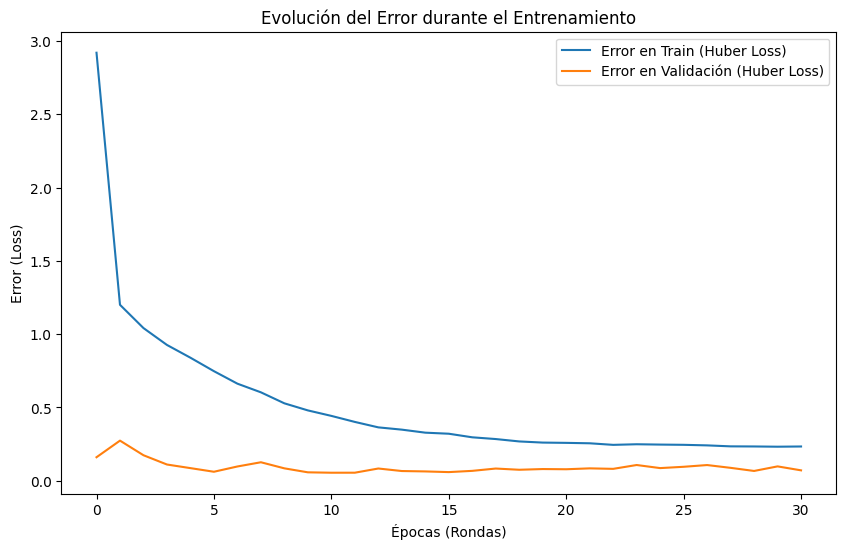

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step

--- RESULTADOS FINALES REALES EN TEST ---
Error Absoluto Medio (MAE): 103,191.07 €
R-Cuadrado (R2): 0.6146


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Ver cómo ha aprendido la red con un gráfico
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Error en Train (Huber Loss)')
plt.plot(history.history['val_loss'], label='Error en Validación (Huber Loss)')
plt.title('Evolución del Error durante el Entrenamiento')
plt.xlabel('Épocas (Rondas)')
plt.ylabel('Error (Loss)')
plt.legend()
plt.show()

# 2. Hacer predicciones sobre los datos de TEST (en escala logarítmica)
test_predictions_log = model.predict(X_test_scaled)

# --- EL ESCUDO MATEMÁTICO (Clipping) ---
# Limitamos las predicciones logarítmicas a un máximo de 15 para evitar 
# que la exponencial explote (np.expm1(15) son unos 3.2 millones de euros).
safe_test_predictions_log = np.clip(test_predictions_log, a_min=0, a_max=15)
# ---------------------------------------

# 3. Convertir los logaritmos a EUROS reales de forma segura
test_predictions_euros = np.expm1(safe_test_predictions_log)

# Aseguramos que y_test se maneje bien si es una serie de Pandas
y_test_array = y_test.values if hasattr(y_test, 'values') else y_test
y_test_euros = np.expm1(y_test_array)

# 4. Calcular métricas finales 
mae = mean_absolute_error(y_test_euros, test_predictions_euros)
r2 = r2_score(y_test_euros, test_predictions_euros)

print("\n--- RESULTADOS FINALES REALES EN TEST ---")
print(f"Error Absoluto Medio (MAE): {mae:,.2f} €")
print(f"R-Cuadrado (R2): {r2:.4f}")

In [10]:
val_predictions_log = model.predict(X_val)
safe_val_predictions_log = np.clip(val_predictions_log, a_min=0, a_max=15)
params = {
    "batch_size":fit_params["batch_size"],
    "epochs":fit_params["epochs"],
}

record = pd.read_csv("../models/models_log.csv")

val_r2 = r2_score(np.expm1(y_val), np.expm1(safe_val_predictions_log))
val_mae = mean_absolute_error(np.expm1(y_val), np.expm1(safe_val_predictions_log))

buy_r2 = record.loc[record["model"] == "buy_model", "r2"]
record_r2_log = 0 if buy_r2.empty or buy_r2.isna().all() else buy_r2.max()
print(val_r2, record_r2_log)
if val_r2 > record_r2_log:
    model_type = "buy_model_DL",
    model_name = "modelo_compras_dl.keras",
    best_params = params,
    best_r2 = val_r2,
    best_mae = val_mae

    entry = {
        "model": "buy_model",
        "model_type": model_type,
        "model_name": model_name,
        "r2": best_r2,
        "mae": best_mae,
    }
    entry_df = pd.DataFrame(entry, index=[0])
    params_str = str(best_params)
    entry_df["params"] = params_str

    new_record = pd.concat([record, entry_df], ignore_index=True)

    new_record.to_csv("../models/models_log.csv", index=False)
    # 1. Guardar el modelo de la Red Neuronal (El "Cerebro")
    model.save(f'../models/modelo_compras_dl.keras')
    
    print(f"✅ Modelo de Red Neuronal guardado como {model_name}")
    print("\n¡Todo empaquetado y listo!")

else:
    print("No se mejoró el modelo. No se guardará.")

118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 378us/step
0.6163494465776054 0
✅ Modelo de Red Neuronal guardado como ('modelo_compras_dl.keras',)

¡Todo empaquetado y listo!
